### Workflow
1. Create state schema
2. Create Nodes
3. Create state graph
4. Add nodes
5. Add edges
6. Compile
7. Invoke

1. Create state

In [4]:
from typing import TypedDict

class State(TypedDict):
    message : str

2. Create nodes

In [5]:
def say_hello(State):
    State["message"] = "Hello"
    return State

In [ ]:
def add_name(State):
    State["message"] += "World"
    return State

3. Create state graph

In [7]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)

4. Add Nodes

In [8]:
builder.add_node("say_hello", say_hello)
builder.add_node("add_name", add_name)

5. Add Edges

In [9]:
builder.add_edge(START, "say_hello")
builder.add_edge("say_hello", "add_name")
builder.add_edge("add_name", END)

6. Compile

In [10]:
graph = builder.compile()

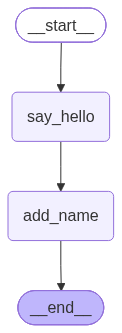

In [11]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

8. Invoke

In [12]:
result = graph.invoke({"message":"Hero"})

print(result)

{'message': 'HelloWorld'}
